# Chapter 7: Working with Text Data

We already discussed continuous and categorical features, but a third type of feature is text.

In [1]:
#
# to avoid standard error messages containing full paths in my local machine
#
import warnings
warnings.filterwarnings('ignore')

In [2]:
# create an environment where we can import all the needed modules
import sys, os
sys.path.append('../introduction_to_ml_with_python')
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin"
import mglearn

In [3]:
!tree -L 2 ../introduction_to_ml_with_python/data/aclImdb

../introduction_to_ml_with_python/data/aclImdb
├── README
├── imdb.vocab
├── imdbEr.txt
├── test
│   ├── labeledBow.feat
│   ├── neg
│   ├── pos
│   ├── urls_neg.txt
│   └── urls_pos.txt
└── train
    ├── labeledBow.feat
    ├── neg
    ├── pos
    ├── unsup
    ├── unsupBow.feat
    ├── urls_neg.txt
    ├── urls_pos.txt
    └── urls_unsup.txt

8 directories, 11 files


In [4]:
# load the data
from sklearn.datasets import load_files

review_train       = load_files("../introduction_to_ml_with_python/data/aclImdb/train/")
text_train, ytrain = review_train.data, review_train.target
print(type(text_train), len(text_train), text_train[1])

<class 'list'> 75000 b"Amount of disappointment I am getting these days seeing movies like Partner, Jhoom Barabar and now, Heyy Babyy is gonna end my habit of seeing first day shows.<br /><br />The movie is an utter disappointment because it had the potential to become a laugh riot only if the d\xc3\xa9butant director, Sajid Khan hadn't tried too many things. Only saving grace in the movie were the last thirty minutes, which were seriously funny elsewhere the movie fails miserably. First half was desperately been tried to look funny but wasn't. Next 45 minutes were emotional and looked totally artificial and illogical.<br /><br />OK, when you are out for a movie like this you don't expect much logic but all the flaws tend to appear when you don't enjoy the movie and thats the case with Heyy Babyy. Acting is good but thats not enough to keep one interested.<br /><br />For the positives, you can take hot actresses, last 30 minutes, some comic scenes, good acting by the lead cast and the 

In [5]:
# do some formatting. Not sure if this applies now
text_train = [doc.replace(b"<br />", b" ") for doc in text_train]

In [6]:
# just looking into the data more
import numpy as np
print("Samples per class", np.bincount(ytrain))

Samples per class [12500 12500 50000]


In [7]:
# load test data

review_test      = load_files("../introduction_to_ml_with_python/data/aclImdb/test/")
text_test, ytest = review_test.data, review_test.target
text_test        = [doc.replace(b"<br />", b" ") for doc in text_test]
print(len(text_test), np.bincount(ytest))



25000 [12500 12500]


## Representing Text Data as a Bag of Words

One of the most simple but effective and commonly used ways to represent text for machine learning is using the **bag-of-words** representation. By discarding most of the structure of the input text (e.g., chapters, paragraphs, sentences, & formatting), and only counting *how often each word appears in each text* in the corpus, we create an image of representing text as a bag.

This approach consist of three steps:
1. *Tokenization*. Split each document into words that appear in it (called *tokens*)
2. *Vocabulary building*. Collect a vocabulary of all words that appear in any of the documents, and number them (say, in alphabetical order)
3. *Encoding*. For each document, count how often each of the words in the vocabulary appear in this document.

In [8]:
# let's ue a transformer to an implementation ourselves
from sklearn.feature_extraction.text import CountVectorizer

bards_words = ["The fool doth think he is wise,", "but the wise man knows himself to be a fool"]
vect        = CountVectorizer()
vect.fit(bards_words)

print(len(vect.vocabulary_))
print(vect.vocabulary_)

# create the bag
bag_of_words = vect.transform(bards_words)
print(repr(bag_of_words))

13
{'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}
<2x13 sparse matrix of type '<class 'numpy.int64'>'
	with 16 stored elements in Compressed Sparse Row format>


In [9]:
# 
# it's a sparse matrix, so to visualize, we need to
# convert it to a dense matrix
#
print(bag_of_words.toarray()) # neither string contains a word twice, so it's either 0 or 1

[[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


In [10]:
# apply it to our data now
vect   = CountVectorizer().fit(text_train)
xtrain = vect.transform(text_train)
print(repr(xtrain))

<75000x124255 sparse matrix of type '<class 'numpy.int64'>'
	with 10315542 stored elements in Compressed Sparse Row format>


In [11]:
# get each feature
feature_names = vect.get_feature_names()
print("Number of features: {}".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:20]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 2000th feature:\n{}".format(feature_names[::2000]))

Number of features: 124255
First 20 features:
['00', '000', '0000', '0000000000000000000000000000000001', '0000000000001', '000000001', '000000003', '00000001', '000001745', '00001', '0001', '00015', '0002', '0007', '00083', '000ft', '000s', '000th', '001', '002']
Features 20010 to 20030:
['cheapen', 'cheapened', 'cheapening', 'cheapens', 'cheaper', 'cheapest', 'cheapie', 'cheapies', 'cheapjack', 'cheaply', 'cheapness', 'cheapo', 'cheapozoid', 'cheapquels', 'cheapskate', 'cheapskates', 'cheapy', 'chearator', 'cheat', 'cheata']
Every 2000th feature:
['00', '_require_', 'aideed', 'announcement', 'asteroid', 'banquière', 'besieged', 'bollwood', 'btvs', 'carboni', 'chcialbym', 'clotheth', 'consecration', 'cringeful', 'deadness', 'devagan', 'doberman', 'duvall', 'endocrine', 'existent', 'fetiches', 'formatted', 'garard', 'godlie', 'gumshoe', 'heathen', 'honoré', 'immatured', 'interested', 'jewelry', 'kerchner', 'köln', 'leydon', 'lulu', 'mardjono', 'meistersinger', 'misspells', 'mumblecore'

In [12]:
# let's try creating a model for this before moving further
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = cross_val_score(LogisticRegression(), xtrain, ytrain, cv = 5)
print(np.mean(scores)) # 0.67..

0.6720266666666668


In [13]:
# let's find a parameter to better tune the model
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
grid       = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(xtrain, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_)) # 0.89, so only slightly better
print("Best parameters: ", grid.best_params_)

Best cross-validation score: 0.68
Best parameters:  {'C': 0.01}


In [14]:
# now apply it on the test
xtest = vect.transform(text_test)
print(grid.score(xtest, ytest)) # this is poor..

0.10864


We can improve this by removing some of the noise. For example, a token that only appears in only a single document is unlikely to appear in the test set and is therefore not helpful.

In [15]:
vect   = CountVectorizer(min_df=5).fit(text_train) # token must show up in at least 5 documents
xtrain = vect.transform(text_train)
print(repr(xtrain))

<75000x44532 sparse matrix of type '<class 'numpy.int64'>'
	with 10191240 stored elements in Compressed Sparse Row format>


In [16]:
feature_names = vect.get_feature_names()
print("First 50 features:\n{}".format(feature_names[:50]))
print("Features 20010 to 20030:\n{}".format(feature_names[20010:20030]))
print("Every 700th feature:\n{}".format(feature_names[::700]))

First 50 features:
['00', '000', '001', '007', '00am', '00pm', '00s', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '100', '1000', '1001', '100k', '100th', '100x', '101', '101st', '102', '103', '104', '105', '106', '107', '108', '109', '10am', '10pm', '10s', '10th', '10x', '11', '110', '1100', '110th', '111', '112', '1138', '115', '116', '117', '11pm', '11th']
Features 20010 to 20030:
['inert', 'inertia', 'inescapable', 'inescapably', 'inevitability', 'inevitable', 'inevitably', 'inexcusable', 'inexcusably', 'inexhaustible', 'inexistent', 'inexorable', 'inexorably', 'inexpensive', 'inexperience', 'inexperienced', 'inexplicable', 'inexplicably', 'inexpressive', 'inextricably']
Every 700th feature:
['00', 'accountability', 'alienate', 'appetite', 'austen', 'battleground', 'bitten', 'bowel', 'burton', 'cat', 'choreographing', 'collide', 'constipation', 'creatively', 'dashes', 'descended', 'dishing', 'dramatist', 'ejaculation', 'epitomize', 'extinguished', 'figment', 'forgot'

In [17]:
# how did the model do
grid = GridSearchCV(LogisticRegression(), param_grid=param_grid, cv=5)
grid.fit(xtrain, ytrain)
print(grid.best_score_)

# the score is the same, so our model isn't more accurate,
# but we removed uninformative features, making the model
# process the data faster

0.6799999999999999


Another way to denoise text data is to get rid of uninformative words that are *too frequent* to be imformative. There are two methods to do so. Using a language-specific list of stopwords, or discarding words that appear too frequently.

In [18]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print(len(ENGLISH_STOP_WORDS), list(ENGLISH_STOP_WORDS)[::10])

318 ['nevertheless', 'was', 'we', 'through', 'since', 'meanwhile', 'sometimes', 'sixty', 'therefore', 'among', 'as', 'him', 'already', 'would', 'whose', 'name', 'in', 'everywhere', 'yet', 'becoming', 'made', 'twenty', 'become', 'fire', 'some', 'call', 'last', 'you', 'ie', 'both', 'i', 'wherever']


In [19]:
# the function has these words built-in
vect   = CountVectorizer(min_df=5, stop_words="english").fit(text_train)
xtrain = vect.transform(text_train)
print(repr(xtrain))

#
# max_df can be used to remove words based on a threshold
#

<75000x44223 sparse matrix of type '<class 'numpy.int64'>'
	with 6577418 stored elements in Compressed Sparse Row format>


In [20]:
# how does it perform now
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(xtrain, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_)) # improve to 0.71

Best cross-validation score: 0.71


## Rescaling the Data with tf-idf

Instead of dropping features that are deemed unimportant, another approach is to rescale features by how informative we expect them to be. One of the most common ways to do this is using the **term frequency-inverse document frequency (tf-idf)** method. The intuition of this method is to give high weight to any term that appears often in a particular document, but not in many documents in the corpus.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline

pipe       = make_pipeline(TfidfVectorizer(min_df=5, norm=None), LogisticRegression())
param_grid = {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10]}
grid       = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_)) # 0.72, so some improvement


Best cross-validation score: 0.72


In [22]:
#
# find which words the model found to be important (i.e., informative)
#

vectorizer      = grid.best_estimator_.named_steps["tfidfvectorizer"]
xtrain          = vectorizer.transform(text_train)
max_value       = xtrain.max(axis = 0).toarray().ravel()
sorted_by_tfidf = max_value.argsort()
feature_names   = np.array(vectorizer.get_feature_names())

print("Features with lowest tfidf:\n{}".format(feature_names[sorted_by_tfidf[:20]]))
print("Features with highest tfidf: \n{}".format(feature_names[sorted_by_tfidf[-20:]]))

Features with lowest tfidf:
['remained' 'acclaimed' 'combines' 'rapidly' 'uniformly' 'diverse'
 'avoiding' 'fills' 'feeble' 'admired' 'wherever' 'admission' 'abound'
 'starters' 'assure' 'pivotal' 'comprehend' 'deliciously' 'strung'
 'inadvertently']
Features with highest tfidf: 
['nukie' 'reno' 'dominick' 'taz' 'ling' 'rob' 'victoria' 'turtles'
 'khouri' 'lorenzo' 'id' 'zizek' 'elwood' 'nikita' 'rishi' 'timon'
 'titanic' 'zohan' 'pammy' 'godzilla']


We can also find the words that have low inverse document frequency, that is, those that appear frequently and are therefore deemed less important.

In [23]:
sorted_by_idf = np.argsort(vectorizer.idf_)
print("Features with lowest idf:\n{}".format(feature_names[sorted_by_idf[:100]]))

Features with lowest idf:
['the' 'and' 'of' 'to' 'this' 'is' 'it' 'in' 'that' 'but' 'for' 'with'
 'was' 'as' 'on' 'movie' 'not' 'one' 'be' 'have' 'are' 'film' 'you' 'all'
 'at' 'an' 'by' 'from' 'so' 'like' 'who' 'there' 'they' 'his' 'if' 'out'
 'just' 'about' 'he' 'or' 'has' 'what' 'some' 'can' 'good' 'when' 'more'
 'up' 'time' 'very' 'even' 'only' 'no' 'see' 'would' 'my' 'story' 'really'
 'which' 'well' 'had' 'me' 'than' 'their' 'much' 'were' 'get' 'other' 'do'
 'been' 'most' 'also' 'into' 'don' 'her' 'first' 'great' 'how' 'made'
 'people' 'will' 'make' 'because' 'way' 'could' 'bad' 'we' 'after' 'them'
 'too' 'any' 'then' 'movies' 'watch' 'she' 'think' 'seen' 'acting' 'its'
 'characters']


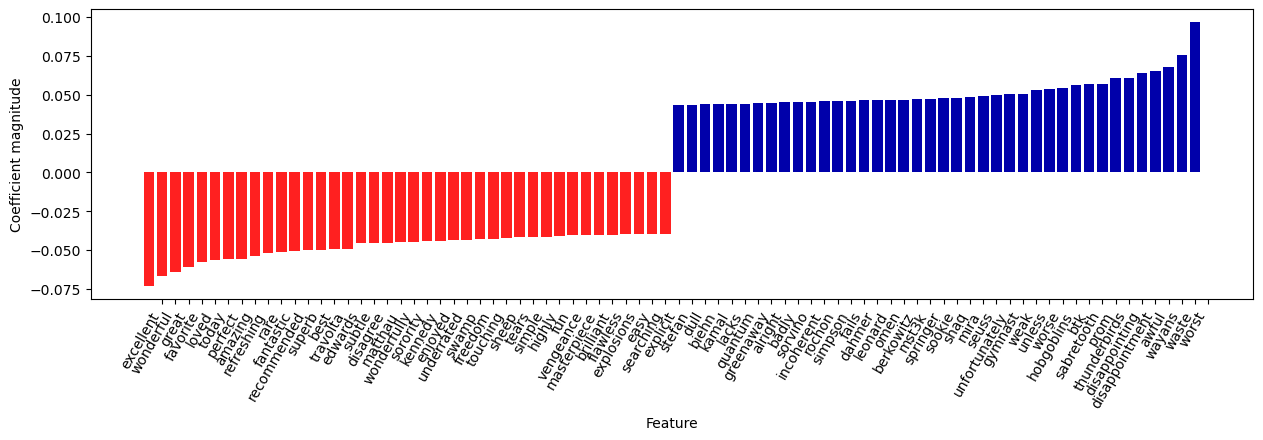

In [24]:
# visualize the coeffients estimate from our model
mglearn.tools.visualize_coefficients(grid.best_estimator_.named_steps["logisticregression"].coef_[0], feature_names, n_top_features=40)

In [25]:
grid.best_estimator_.named_steps["logisticregression"].coef_

array([[ 6.71041246e-03,  3.68973840e-03,  8.33983877e-03, ...,
         2.45146702e-03, -2.00962243e-03,  4.68596044e-03],
       [-1.01602502e-02, -1.30719560e-02, -4.07226198e-03, ...,
         7.09132092e-07, -1.95146637e-03, -2.29595910e-03],
       [ 3.44983773e-03,  9.38221762e-03, -4.26757679e-03, ...,
        -2.45217615e-03,  3.96108880e-03, -2.39000134e-03]])

One of the main disadvantages of using a bag-of-words representation is that the word order is completely discard. Therefore, the two strings *"it's bad, not good at all"* and *"it's good, not bad at all"* have exactly the same representation even though the meanings are inverted.

To capture context, we can capture the counts of pairs or triplets of tokens that appear next to each other. Pairs of tokens are known as *bigrams*, triplets of tokens are known as *trigrams*, and more generally sequences of tokens are known as *n-grams*.

In [26]:
print(bards_words)

['The fool doth think he is wise,', 'but the wise man knows himself to be a fool']


In [27]:
# we can change the pair size using a tuple(min length, max length)
cv = CountVectorizer(ngram_range=(1, 1)).fit(bards_words)
print(len(cv.vocabulary_))
print(cv.get_feature_names_out())

cv = CountVectorizer(ngram_range=(2, 2)).fit(bards_words)
print(len(cv.vocabulary_))
print(cv.get_feature_names_out())

13
['be' 'but' 'doth' 'fool' 'he' 'himself' 'is' 'knows' 'man' 'the' 'think'
 'to' 'wise']
14
['be fool' 'but the' 'doth think' 'fool doth' 'he is' 'himself to'
 'is wise' 'knows himself' 'man knows' 'the fool' 'the wise' 'think he'
 'to be' 'wise man']


For most applications, the minimum number of tokens should be one, as single words often capture a lot of meaning. Adding bigrams helps in most cases. But the higher the pair size, the more features the model will have to deal with and higher likelihood of overfitting.

In [28]:
cv = CountVectorizer(ngram_range=(1, 3)).fit(bards_words)
print(len(cv.vocabulary_))
print(cv.get_feature_names_out())

39
['be' 'be fool' 'but' 'but the' 'but the wise' 'doth' 'doth think'
 'doth think he' 'fool' 'fool doth' 'fool doth think' 'he' 'he is'
 'he is wise' 'himself' 'himself to' 'himself to be' 'is' 'is wise'
 'knows' 'knows himself' 'knows himself to' 'man' 'man knows'
 'man knows himself' 'the' 'the fool' 'the fool doth' 'the wise'
 'the wise man' 'think' 'think he' 'think he is' 'to' 'to be' 'to be fool'
 'wise' 'wise man' 'wise man knows']


In [29]:
# use grid search to find the best n-gram range

pipe       = make_pipeline(TfidfVectorizer(min_df=5), LogisticRegression())
param_grid = {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10, 100], 
              "tfidfvectorizer__ngram_range": [(1, 1), (1, 2), (1, 3)]}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(text_train, ytrain)
print("Best cross-validation score: {:.2f}".format(grid.best_score_))
print("Best parameters:\n{}".format(grid.best_params_)) # 0.71 accurate, NOTE: took ~47 minutes to run

Best cross-validation score: 0.71
Best parameters:
{'logisticregression__C': 10, 'tfidfvectorizer__ngram_range': (1, 2)}


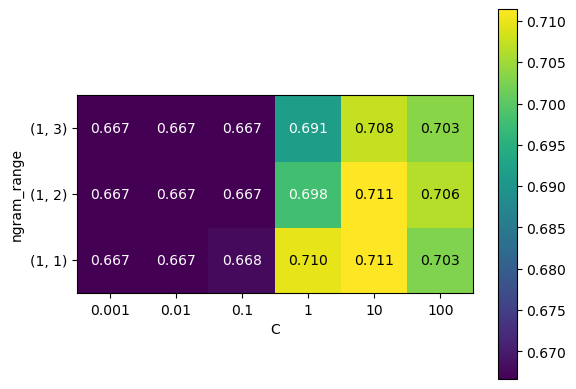

In [30]:
# visualize our parameter space
import matplotlib.pyplot as plt

scores = grid.cv_results_['mean_test_score'].reshape(-1, 3).T

# visualize heat map
heatmap = mglearn.tools.heatmap(scores, xlabel="C", ylabel="ngram_range", cmap="viridis", fmt="%.3f", xticklabels=param_grid['logisticregression__C'], yticklabels=param_grid['tfidfvectorizer__ngram_range'])
plt.colorbar(heatmap)

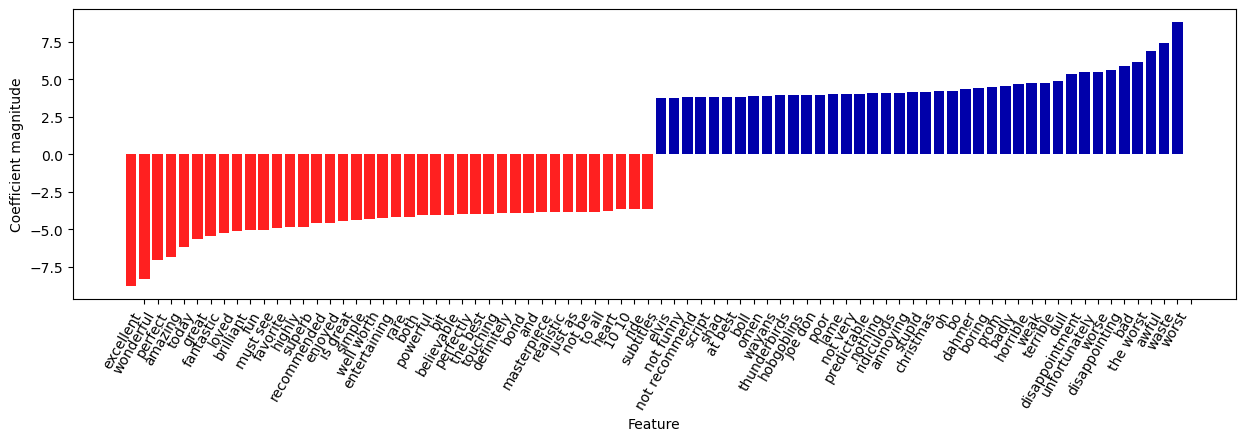

In [31]:
# now look at the coefficients
vect          = grid.best_estimator_.named_steps['tfidfvectorizer']
feature_names = np.array(vect.get_feature_names())
coef          = grid.best_estimator_.named_steps['logisticregression'].coef_[0]
mglearn.tools.visualize_coefficients(coef, feature_names, n_top_features=40)

In [32]:
# coefficients for tri-grams
# mask = np.array([len(feature.split(" ")) for feature in feature_names]) == 3
# mglearn.tools.visualize_coefficients(coef.ravel()[mask], feature_names[mask], n_top_features=40)

## Advanced Tokenization, Stemming, and Lemmatization

One way of improving the model is by improving the tokenization step. One approach towards achieving this feat is by representing each word by its *word stem*, which involves identifying (or *conflating*) all the words that have the same word stem. 
- If this is done by using a rule-based heuristic, like dropping common suffixes, it is usually referred to as *stemming*. 
- If instead a dictionary of known word forms is used and the role of the word in the sentence is taken into account, the process is referred to as *lemmatization* and the standardized form of the word is referred to as the *lemma*. 

Both processing methods, *lemmization* and *stemming*, are forms of *normalization* that try to extract some normal form of a word.

In [33]:
import spacy
import nltk

#
# load spacy's English language models &
# instantiate nltk's Porter stemmer
#
en_nlp  = spacy.load("en_core_web_sm")
stemmer = nltk.stem.PorterStemmer()

# compare lemmatization in spacy with stemming in nltk
def compare_normalization(doc: str):
    doc_spacy = en_nlp(doc) # tokenize document in spacy
    print("Lemmatizatoin: ")
    print([token.lemma_ for token in doc_spacy])
    print("Stemming: ")
    print([stemmer.stem(token.norm_.lower()) for token in doc_spacy])

compare_normalization(u"Our meeting today was worse than yesterday, "
                       "I'm scared of meeting the clients tomorrow.")


Lemmatizatoin: 
['our', 'meeting', 'today', 'be', 'bad', 'than', 'yesterday', ',', 'I', 'be', 'scared', 'of', 'meet', 'the', 'client', 'tomorrow', '.']
Stemming: 
['our', 'meet', 'today', 'wa', 'wors', 'than', 'yesterday', ',', 'i', 'am', 'scare', 'of', 'meet', 'the', 'client', 'tomorrow', '.']


In [34]:
# we can create our own tokenizer using regex
import re
from spacy.tokens import Doc

regexp           = re.compile('(?u)\\b\\w\\w+\\b')
old_tokenizer    = en_nlp.tokenizer # replace
en_nlp.tokenizer = lambda string: old_tokenizer.tokens_from_list(regexp.findall(string))

def custom_tokenizer(doc: str):
    words     = regexp.findall(doc)
    doc_spacy = Doc(en_nlp.vocab, words=words)
    for name, proc in en_nlp.pipeline:
        if (name not in ["ner", "parser"]):
            doc_spacy = proc(doc_spacy)
            
    return [token.lemma_ for token in doc_spacy]

lemma_vect = CountVectorizer(tokenizer=custom_tokenizer, min_df=5)

In [35]:
# transform text_train using CountVectorizer with lemmaization
x_train_lemma = lemma_vect.fit_transform(text_train)
print(x_train_lemma.shape)

# standard CountVectorizer for reference
vect   = CountVectorizer(min_df=5).fit(text_train)
xtrain = vect.transform(text_train)
print(xtrain.shape) # this took ~10 minutes to run

# we should see a reduction in elements (44 K -> 35 K)

(75000, 35262)
(75000, 44532)


In [36]:
# apply grid search
from sklearn.model_selection import StratifiedShuffleSplit

# build a grid search using only 1% of the data as the training set
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10]}
cv         = StratifiedShuffleSplit(n_splits=5, test_size=0.99, train_size=0.01, random_state=0)
grid       = GridSearchCV(LogisticRegression(), param_grid, cv=cv)

# perform grid search with standard CountVectorizer
grid.fit(xtrain, ytrain)
print("Best cross-validation score", "(standard CountVectorizer): {:.3f}".format(grid.best_score_))
# perform grid search with lemmatization
grid.fit(x_train_lemma, ytrain)
print("Best cross-validation score", "(lemmatization): {:.3f}".format(grid.best_score_))

Best cross-validation score (standard CountVectorizer): 0.666
Best cross-validation score (lemmatization): 0.666


## Topic Modeling and Document Clustering

One particular technique that is often applied to text data it *topic modeling*, which is an umbrella term describing the task of assigning each document to one or multiple topics, usually without supervision

A popular method to implement this technique is known as **Latent Dirichlet Allocation (LDA)**.

## Latent Dirichlet Allocation (LDA)

The LDA model tries to find groups of words (the topics) that appear together frequently. LDA also requires that each document can be understood as a "mixture" of a subset of the topics.

It is important to understand for the machine learning model a "topic" might not be what we would normally call a topic in everyday speech, but that it resembles more the componets extracted by PCA or NMF, which might or might not have a semantic meaning

In [37]:
# remove common words to make it easier on the model
vect = CountVectorizer(max_features=10000, max_df=.15)
x    = vect.fit_transform(text_train)

In [38]:
from sklearn.decomposition import LatentDirichletAllocation

lda        = LatentDirichletAllocation(n_components = 10, learning_method="batch", max_iter=25, random_state=0)
doc_topics = lda.fit_transform(x) # ~6.5 minutes to run

We can also see how important each word is for each topic

In [39]:
print(lda.components_.shape)

# For each topic (a row in the components_), sort the features (ascending)
# Invert rows with [:, ::-1] to make sorting descending
sorting = np.argsort(lda.components_, axis=1)[:, ::-1]

# Get the feature names from the vectorizer
feature_names = np.array(vect.get_feature_names())

mglearn.tools.print_topics(topics=range(10), feature_names=feature_names, sorting=sorting, topics_per_chunk=5, n_words=10)

(10, 10000)
topic 0       topic 1       topic 2       topic 3       topic 4       
--------      --------      --------      --------      --------      
action        worst         comedy        role          funny         
horror        nothing       john          cast          saw           
original      didn          joe           john          10            
effects       minutes       town          performance   book          
game          actually      funny         version       years         
special       actors        new           young         again         
quite         funny         plays         star          thought       
genre         re            role          play          didn          
gore          script        harry         musical       am            
pretty        want          school        played        show          


topic 5       topic 6       topic 7       topic 8       topic 9       
--------      --------      --------      --------      -------

In [40]:
# increase the number of topics
lda100        = LatentDirichletAllocation(n_components = 100, learning_method="batch", max_iter=25, random_state=0)
doc_topics100 = lda100.fit_transform(x) # ~6.5 minutes to run

In [41]:
# only see the top candidatees
topics        = np.array([7, 16, 24, 25, 28, 36, 37, 45, 51, 53, 54, 63, 89, 97])
sorting       = np.argsort(lda100.components_, axis=1)[:, ::-1]
feature_names = np.array(vect.get_feature_names())
mglearn.tools.print_topics(topics=topics, feature_names=feature_names, sorting=sorting, topics_per_chunk=7, n_words=20)

topic 7       topic 16      topic 24      topic 25      topic 28      topic 36      topic 37      
--------      --------      --------      --------      --------      --------      --------      
williams      car           camera        effects       frank         family        work          
robin         shot          silent        special       race          father        art           
fox           camera        face          monster       kelly         mother        style         
hood          shots         moment        creature      sinatra       son           music         
andrew        looks         sequence      giant         singer        daughter      cinema        
wolf          director      chaplin       monsters      day           brother       director      
tracy         look          opening       cgi           pat           boy           cinematography
food          sound         facial        creatures     ruth          parents       beautiful     
iron      

In [42]:
# examine topic #45
# sort by weight of "music" topic 45
music = np.argsort(doc_topics100[:, 45])[::-1]
# print the five documents where the topic is most important
for i in music[:10]:
# pshow first two sentences
    print(b".".join(text_train[i].split(b".")[:2]) + b".\n")


b'This unpleasant film has little to recommend it. Dolph Lundgren gives a performance that is better than either this script or his other action films have allowed.\n'
b"The film chooses to be sci-fi and then it chooses to have melodrama as well? Doesn't work when there is little attention to acting, and the script is poor. There is one scene in particular that goes on too long and you just can't take it seriously, but let's have your viewing ruin it for you!.\n"
b"Secrets and Lies is my favourite movie so I was keen to see this. Unfortunately, it doesn't work on any level - the plot is unbelieveable and contrived, and the characters a little annoying.\n"
b"A dreary, hopelessly predictable film set in a most unpleasant setting (lower Coachella Valley). Acting is as amateurish as any I've seen.\n"
b'A good example of what you get when a successful actor directs his own movie with himself as the star. It works on occasion, but here you get the distinct feeling that some input from the ou

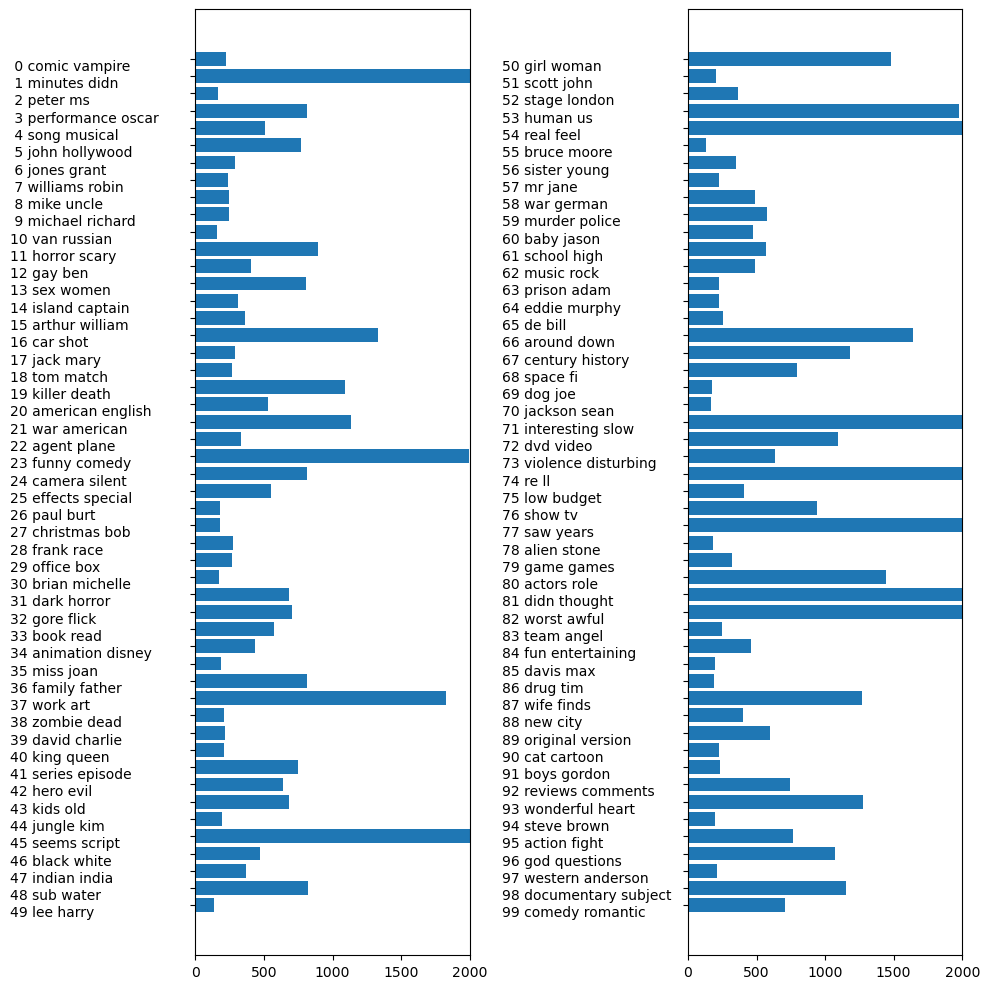

In [43]:
# visualize the sums over all topics
fig, ax     = plt.subplots(1, 2, figsize=(10, 10))
topic_names = ["{:>2} ".format(i) + " ".join(words) for i, words in enumerate(feature_names[sorting[:, :2]])]

    # two column bar chart:
for col in [0, 1]:
    start = col * 50
    end   = (col + 1) * 50
    ax[col].barh(np.arange(50), np.sum(doc_topics100, axis=0)[start:end])
    ax[col].set_yticks(np.arange(50))
    ax[col].set_yticklabels(topic_names[start:end], ha="left", va="top")
    ax[col].invert_yaxis()
    ax[col].set_xlim(0, 2000)
    yax = ax[col].get_yaxis()
    yax.set_tick_params(pad=130)
plt.tight_layout()